In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,          # Use LaTeX rendering (requires LaTeX installed)
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 12            # Set all text to 12 pt
})

from tsp_backend import simmulated_annealing_tsp, nearest_neighbor_tsp, plot_tsp_route, calculate_route_cost, constant_traffic_factor_func, make_distance_matrix, check_if_in_polygon


In [2]:
def traffic_factor_no_traffic(cost : float) -> float:
    return constant_traffic_factor_func(1.0, 0.0, cost)

def traffic_factor_with_traffic(cost : float) -> float:
    return constant_traffic_factor_func(10.0, 4.0, cost)

In [3]:
def plot_tsp_route_stepwise(nodes: np.ndarray,
                            route: np.ndarray,
                            traffic_polygon: np.ndarray = None,
                            cost: float = None,
                            output_path : str = None, 
                            figsize=(4, 4),
                            arrow_width=0.006,
                            arrow_color='lightblue',
                            node_dot_size=50,
                            node_color='black',
                            want_axis=True,
                            close_tour=True):
    """
    Plots the TSP route progressively:
    step 0  -> no arrows
    step 1  -> first arrow
    step 2  -> first 2 arrows
    ...
    step N -> all arrows (complete route)
    """

    if route is None:
        route = np.arange(nodes.shape[0])

    coords = nodes[route]
    n = len(coords)

    # Precompute direction vectors
    dx = coords[1:, 0] - coords[:-1, 0]
    dy = coords[1:, 1] - coords[:-1, 1]

    # Number of steps (edges)
    total_edges = n - 1
    if close_tour:
        total_edges += 1

    for step in range(total_edges + 1):

        plt.figure(figsize=figsize)

        # ---- draw nodes ----
        plt.scatter(nodes[:, 0], nodes[:, 1],
                    color=node_color,
                    zorder=1,
                    s=node_dot_size,
                    label="Nodes")

        # starting node
        plt.scatter(coords[0, 0], coords[0, 1],
                    color='red',
                    zorder=2,
                    s=node_dot_size,
                    label="Starting Point")

        # ---- draw arrows progressively ----
        if step > 0:

            # draw intermediate arrows
            num_regular = min(step, n - 1)

            if num_regular > 0:
                plt.quiver(
                    coords[:num_regular, 0],
                    coords[:num_regular, 1],
                    dx[:num_regular],
                    dy[:num_regular],
                    angles='xy',
                    scale_units='xy',
                    scale=1,
                    width=arrow_width,
                    color=arrow_color
                )

            # draw closing edge
            if close_tour and step > n - 1:
                dx_last = coords[0, 0] - coords[-1, 0]
                dy_last = coords[0, 1] - coords[-1, 1]

                plt.quiver(
                    coords[-1, 0],
                    coords[-1, 1],
                    dx_last,
                    dy_last,
                    angles='xy',
                    scale_units='xy',
                    scale=1,
                    width=arrow_width,
                    color=arrow_color
                )

        # ---- optional polygon ----
        if traffic_polygon is not None:
            traffic_patch = plt.Polygon(
                traffic_polygon,
                color='red',
                alpha=0.3,
                label='Traffic Area'
            )
            plt.gca().add_patch(traffic_patch)

        plt.gca().set_aspect('equal')

        title = f"TSP Route - Step {step}"
        if cost is not None:
            title += f", Cost: {cost:.2f}"
        plt.title(title)

        plt.xlim(0, 1)
        plt.ylim(0, 1)

        if want_axis:
            plt.xlabel("X Coordinate")
            plt.ylabel("Y Coordinate")
        else:
            plt.axis(False)

        plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
        plt.tight_layout()

        plt.savefig(f"{output_path}_step_{step}.pdf", transparent=True)
        plt.show()



def plot_tsp_mc_step(nodes : np.array, 
                   current_route : np.array, 
                   trial_route : np.array,
                   current_cost : float,
                   trial_cost : float,
                   traffic_polygon : np.array = None, 
                   output_path : str = None, 
                   figsize=(3.4, 4),
                   current_arrow_width = 0.006,
                   trial_arrow_width = 0.003,
                   current_arrow_color = 'lightblue',
                   trial_arrow_color = 'darkblue',
                   node_dot_size = 50,
                   node_color='black',
                   want_axis=True):
    """plots the TSP route defined by the order of visiting the nodes

    :param nodes: array of coordinates of the N nodes
    :type nodes: np.ndarray (N, d), N: number of nodes, d: dimension
    
    :param route: array of node indices representing the order of visiting the nodes
    :type route: np.ndarray (N,), values in [0, N-1]

    :param traffic_polygon: array of coordinates of the vertices of the polygon representing the traffic area (optional)
    :type traffic_polygon: np.ndarray (M, d), M: number of vertices, d: dimension

    :param output_path: path to save the plot (optional)
    :type output_path: str
    """
    current_coords = nodes[current_route]
    trial_coords = nodes[trial_route]

    plt.figure(figsize=figsize)

    # scatter nodes
    plt.scatter(nodes[:, 0], nodes[:, 1], color=node_color, label='Nodes',zorder = 1, s=node_dot_size)

    # starting point
    plt.scatter(current_coords[0, 0], current_coords[0, 1], color='red', label='Starting Point', zorder = 2, s=node_dot_size)

    if not current_route is None:
        # direction vectors
        dx = current_coords[1:, 0] - current_coords[:-1, 0]
        dy = current_coords[1:, 1] - current_coords[:-1, 1]

        plt.quiver(
            current_coords[:-1, 0],   # arrow start x
            current_coords[:-1, 1],   # arrow start y
            dx,               # x direction
            dy,               # y direction
            angles='xy',
            scale_units='xy',
            scale=1,
            width=current_arrow_width,
            color=current_arrow_color
        )

        #  close the tour
        dx_last = current_coords[0, 0] - current_coords[-1, 0]
        dy_last = current_coords[0, 1] - current_coords[-1, 1]

        plt.quiver(
            current_coords[-1, 0],
            current_coords[-1, 1],
            dx_last,
            dy_last,
            angles='xy',
            scale_units='xy',
            scale=1,
            width=current_arrow_width,
            color=current_arrow_color,
            label=f'Previous Route\nCost: {current_cost:.2f}'
        )
    
        # trial route
        # direction vectors
        dx = trial_coords[1:, 0] - trial_coords[:-1, 0]
        dy = trial_coords[1:, 1] - trial_coords[:-1, 1]

        plt.quiver(
            trial_coords[:-1, 0],   # arrow start x
            trial_coords[:-1, 1],   # arrow start y
            dx,               # x direction
            dy,               # y direction
            angles='xy',
            scale_units='xy',
            scale=1,
            width=trial_arrow_width,
            headwidth=trial_arrow_width*3,
            color=trial_arrow_color
        )

        # close the tour
        dx_last = trial_coords[0, 0] - trial_coords[-1, 0]
        dy_last = trial_coords[0, 1] - trial_coords[-1, 1]

        plt.quiver(
            trial_coords[-1, 0],
            trial_coords[-1, 1],
            dx_last,
            dy_last,
            angles='xy',
            scale_units='xy',
            scale=1,
            width=trial_arrow_width,
            headwidth=trial_arrow_width*3,
            color=trial_arrow_color,
            label=f'TSP Trial Route\nCost: {trial_cost:.2f}'
        )
       

    if traffic_polygon is not None:
        traffic_patch = plt.Polygon(traffic_polygon, color='red', alpha=0.3, label='Traffic Area')
        plt.gca().add_patch(traffic_patch)

    plt.gca().set_aspect('equal')

    if want_axis:
        plt.xlabel('X Coordinate')
        plt.ylabel('Y Coordinate')
    else:
        plt.axis(False)

    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
    plt.tight_layout()

    if output_path is not None:
        plt.savefig(output_path, bbox_inches='tight', transparent=True)

    plt.show()

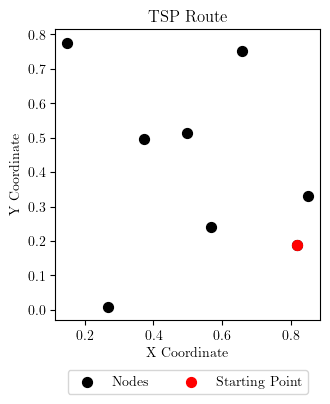

In [4]:
N = 8

rand_nodes_N_10 = np.random.rand(N, 2)

plot_tsp_route(rand_nodes_N_10, None)

In [ ]:
# write nodes into csv file
#np.savetxt('brute_force_tsp_8_nodes.csv', rand_nodes_N_10, delimiter=',')

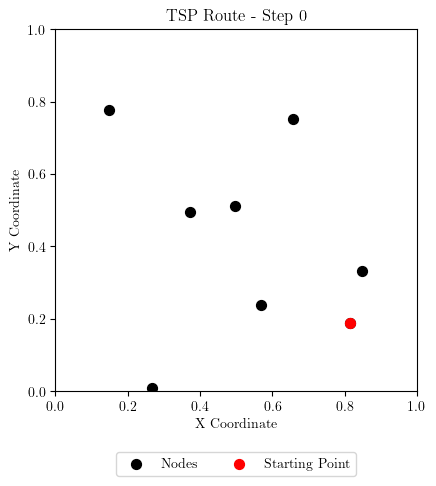

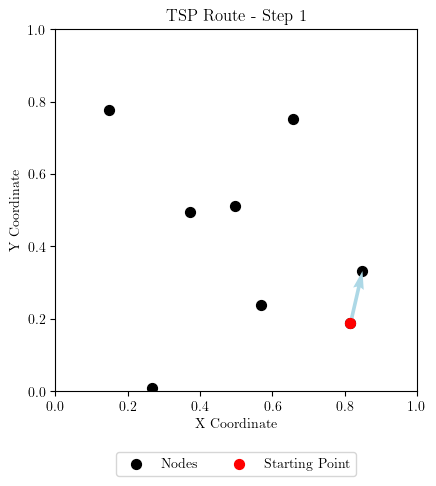

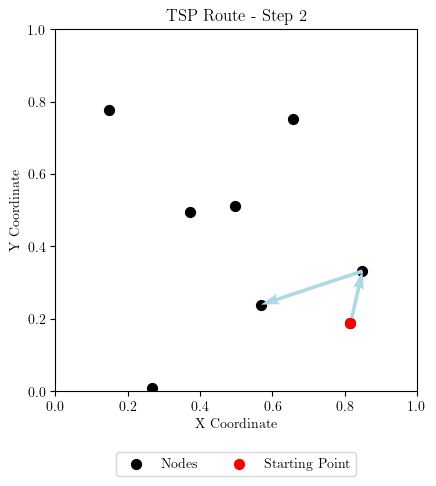

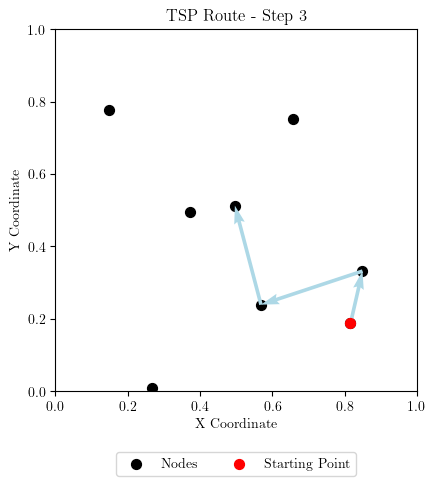

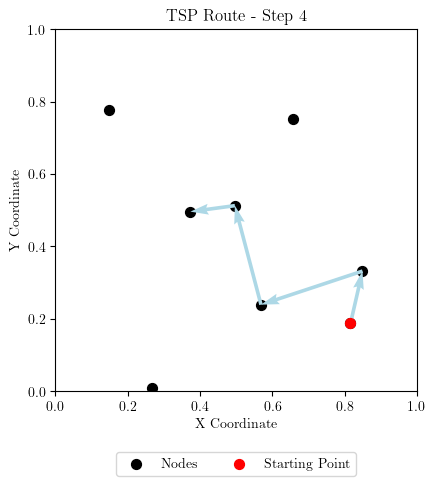

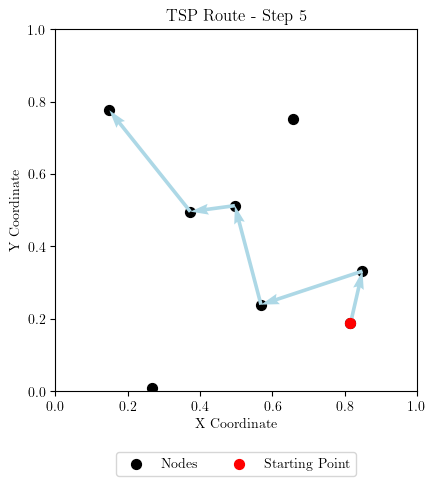

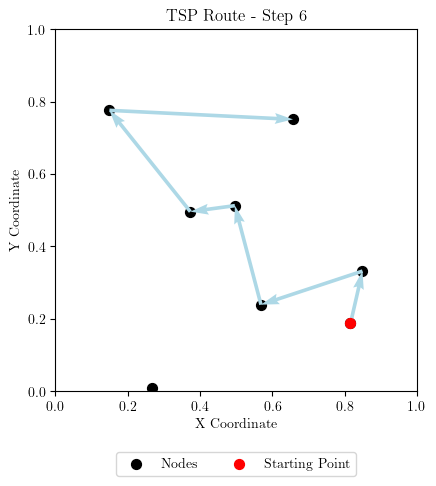

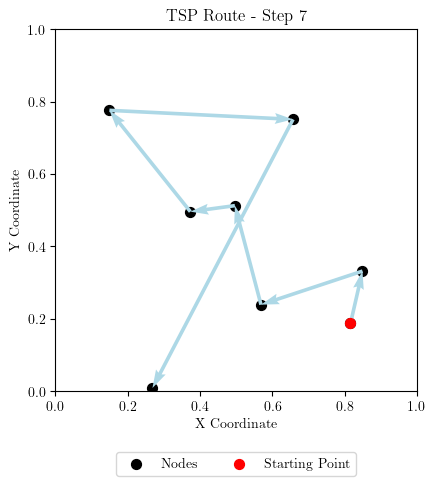

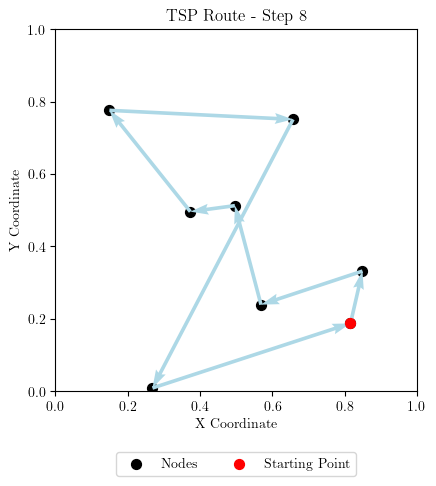

Nearest neighbour route: [0 6 7 5 4 1 2 3]


In [5]:


nearest_neighbour_route_N_10 = nearest_neighbor_tsp(rand_nodes_N_10, start_point_index=0)

plot_tsp_route_stepwise(rand_nodes_N_10, 
                        nearest_neighbour_route_N_10, 
                        output_path="presentation_figures/nearestneighbour_progression", 
                        figsize=(5, 5),
                        arrow_width=0.01)
print("Nearest neighbour route:", nearest_neighbour_route_N_10)

In [6]:
def simmulated_annealing_tsp(
        nodes : np.array, 
        traffic_factor : callable,
        pre_determined_distance_matrix : np.array = None,
        traffic_polygon : np.array = None,
        traffic_start_time : float = 0,
        temperatures : list = [0.1, 0.05, 0.01, 0.001], 
        start_point_index = None, 
        rejection_threshold : list = [20, 200, 2000, 2000], 
        max_iter_per_temperature : int = 16,
        plot_cost : bool = False,
        plot_cost_out_path : str = None) -> np.array:
    """
    simulated annealing algorithm for the time-dependent traveling salesman problem
    
    :param nodes: array of coordinates of the N nodes
    :type nodes: np.ndarray (N, d), N: number of nodes, d: dimension

    :param pre_determined_distance_matrix: pre-determined distance/cost matrix between the nodes (optional, if not given, it will be calculated using the metric function)
    :type pre_determined_distance_matrix: np.ndarray (N, N)

    :param traffic_polygon: array of coordinates of the vertices of the polygon representing the traffic area (optional)
    :type traffic_polygon: np.ndarray (M, d), M: number of vertices, d: dimension

    :param traffic_factor: factor by which the cost of traveling between nodes is multiplied during traffic time
    :type traffic_factor: float >= 1 (1 means no traffic, >1 means traffic)

    :param traffic_start_time: time at which traffic starts (in the same time units as the cost of traveling between nodes)
    :type traffic_start_time: float >= 0

    :param temperatures: list of decreasing temperatures for the annealing
    :type temperatures: list of float

    :param start_point_index: index of the node to start the route from (optional)
    :type start_point_index: int in [0, N-1]

    :param rejection_threshold: list of maximum number of rejections per temperature (optional)
    :type rejection_threshold: list of int, same length as temperatures

    :param max_iter_per_temperature: maximum number of iterations per temperature (optional)
    :type max_iter_per_temperature: int

    :param plot_cost: whether to plot the cost evolution (optional)
    :type plot_cost: bool
    
    :param plot_cost_out_path: path to save the cost plot (optional)
    :type plot_cost_out_path: str

    :return: best route found
    :rtype: np.ndarray (N,), values in [0, N-1]
    """

    N = len(nodes)
    distances = make_distance_matrix(nodes) if pre_determined_distance_matrix is None else pre_determined_distance_matrix

    # determine which nodes are affected by traffic
    if traffic_polygon is not None:
        nodes_in_traffic = np.array([i for i in range(N) if check_if_in_polygon(nodes[i], traffic_polygon)])
    else:
        nodes_in_traffic = np.array([], dtype=int)

    # randomly generate starting permutation and place starting_point_index in the front (w/o duplicates)
    if start_point_index is None:
        # starting_permutation = np.random.permutation(N)
        starting_permutation = nearest_neighbor_tsp(nodes)
    else:
        # starting_permutation = np.concatenate((np.array([start_point_index]), np.random.permutation(np.arange(N)[np.arange(N) != start_point_index])))
        starting_permutation = nearest_neighbor_tsp(nodes, start_point_index=start_point_index)
        
    # step 1
    current_route = np.array(starting_permutation, dtype=int)
    current_cost = calculate_route_cost(nodes, current_route, nodes_in_traffic, distances, traffic_factor, traffic_start_time)
    costs = [current_cost]

    # initial random permutation plot of the route
    plot_tsp_route(nodes,
                   current_route,
                   traffic_polygon=traffic_polygon,
                   cost=current_cost,
                   output_path=f"presentation_figures/simulated_annealing_route_initial.pdf",
                   figsize=(5, 5),
                   arrow_width=0.01)

    trial_route = np.zeros((N, 2), dtype=int)
    trial_cost = 0.0

    num_consec_rejections = 0
    num_iter = 0
    temp_change_points = []
    # step 2
    for temp, rej_thresh in zip(temperatures, rejection_threshold):

        temp_change_points.append(num_iter)

        print(f"Temperature: {temp}, Current Cost: {current_cost}")
        print(f"Current route: {current_route}")
        print(f"num consec rejections: {num_consec_rejections}, num iter: {num_iter}")

        num_consec_rejections = 0

        num_iter = 0
        while num_consec_rejections < rej_thresh and num_iter < max_iter_per_temperature:

            # step 3
            for i in range(0, N):

                j = np.random.choice(np.delete(np.arange(0, N), i))
                
                # step 4
                if j < i: # swap i and j if necessary
                    i, j = j, i
                
                trial_route = current_route.copy()
                trial_route[i:j+1] = trial_route[i:j+1][::-1] # invert order of ith to jth entry

                if not start_point_index is None and trial_route[0] != start_point_index: # ensure starting point is at the front
                    trial_route[trial_route == start_point_index] = trial_route[0]
                    trial_route[0] = start_point_index

                # step 5
                trial_cost = calculate_route_cost(nodes, trial_route, nodes_in_traffic, distances, traffic_factor, traffic_start_time)
                
                plot_tsp_mc_step(nodes,
                                 current_route,
                                 trial_route,
                                 current_cost,
                                 trial_cost,
                                 traffic_polygon=traffic_polygon,
                                 output_path=f"presentation_figures/simulated_annealing_route_temp_{temp}_trial.pdf",
                                 figsize=(5, 5),
                               current_arrow_width=0.01)

                # step 6 & 7
                if trial_cost < current_cost:
                    current_route = trial_route.copy()
                    num_consec_rejections = 0
                    continue

                num_consec_rejections += 1

                x = np.random.rand()
                if x < np.exp((current_cost - trial_cost) / temp):
                    current_route = trial_route.copy()
                    num_consec_rejections = 0

                    # plot the route after accepting a higher cost route
                    plot_tsp_route(nodes, 
                       current_route, 
                       traffic_polygon=traffic_polygon, 
                       cost=current_cost, 
                       output_path=f"presentation_figures/simulated_annealing_route_temp_{temp}_accepted_higher_cost.pdf", 
                       figsize=(5, 5), 
                       arrow_width=0.01)
                                 
                current_cost = calculate_route_cost(nodes, current_route, nodes_in_traffic, distances, traffic_factor, traffic_start_time)
                costs.append(current_cost)
                num_iter += 1

                if num_iter == max_iter_per_temperature:
                    print(f"Reached maximum number of iterations for temperature {temp}. :(")
        
        # After finishing the iterations for the current temperature, plot the route
        plot_tsp_route(nodes, 
                       current_route, 
                       traffic_polygon=traffic_polygon, 
                       cost=current_cost, 
                       output_path=f"presentation_figures/simulated_annealing_route_temp_{temp}.pdf", 
                       figsize=(5, 5), 
                       arrow_width=0.01)
        
        return current_route, costs[-1]

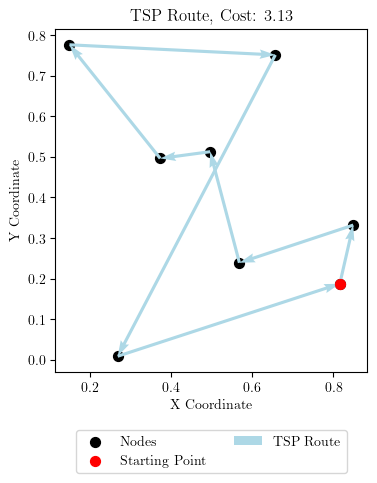

Temperature: 0.1, Current Cost: 3.130095298380769
Current route: [0 1 6 4 7 2 5 3]
num consec rejections: 0, num iter: 0


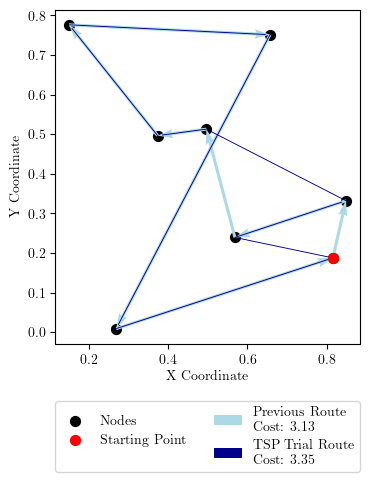

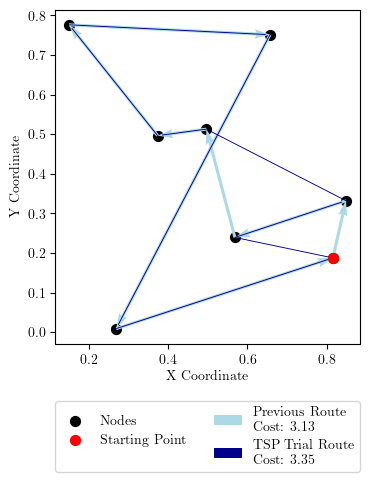

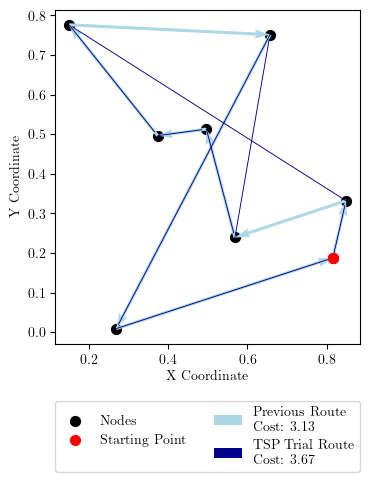

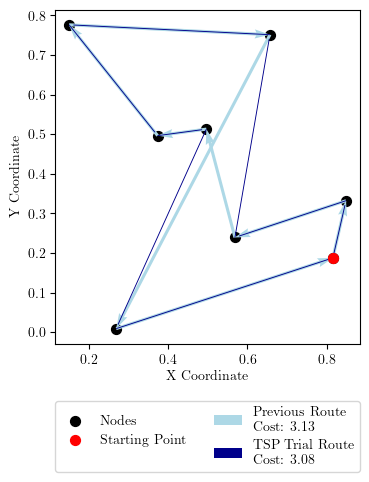

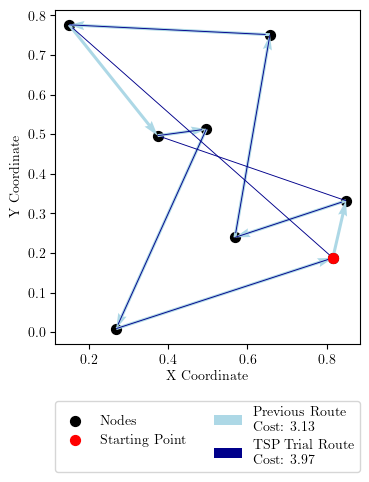

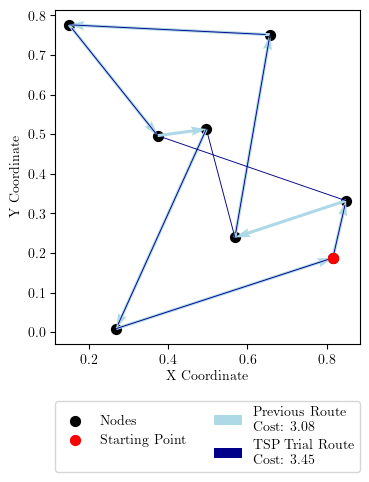

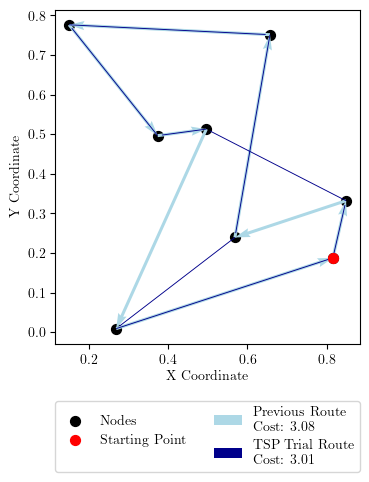

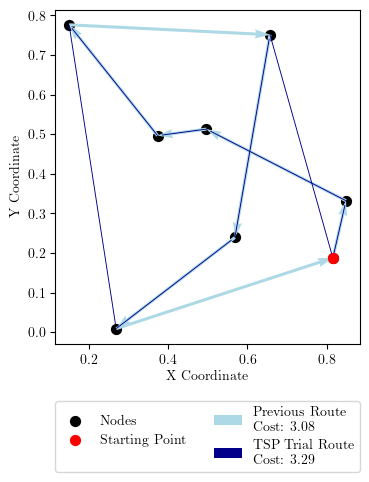

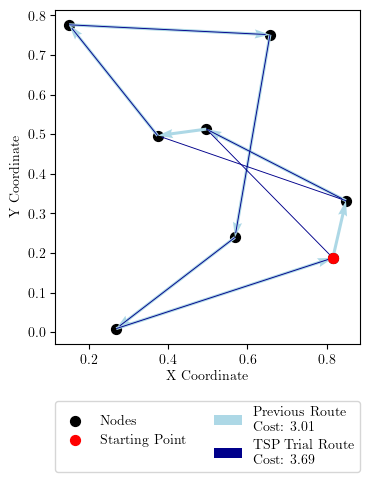

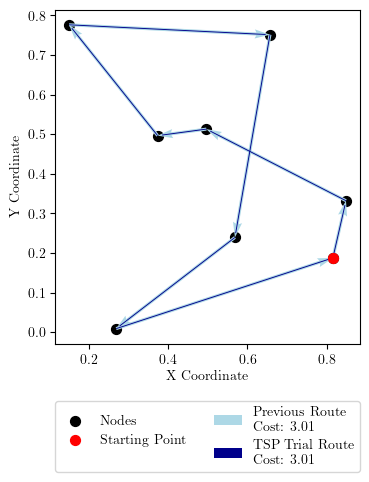

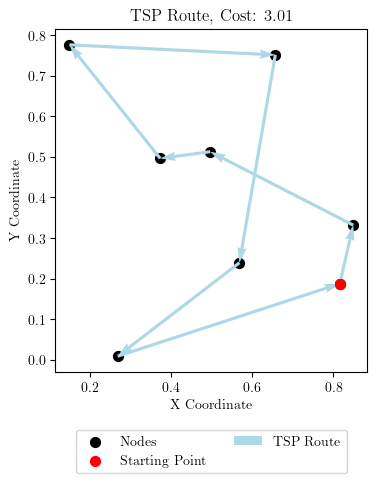

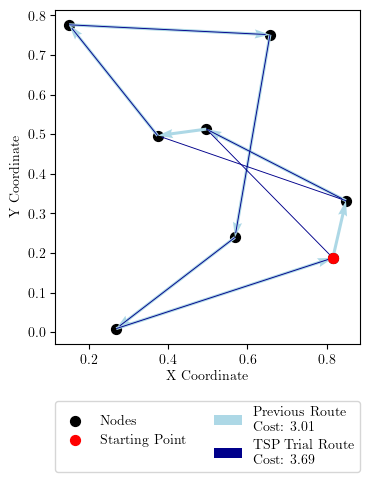

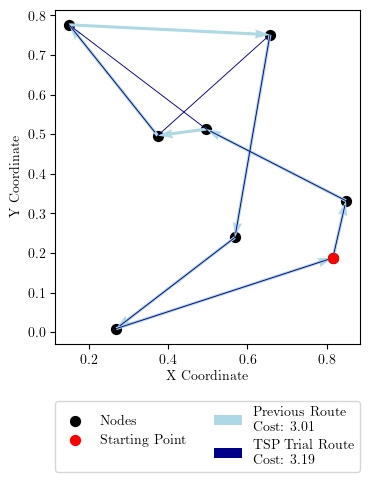

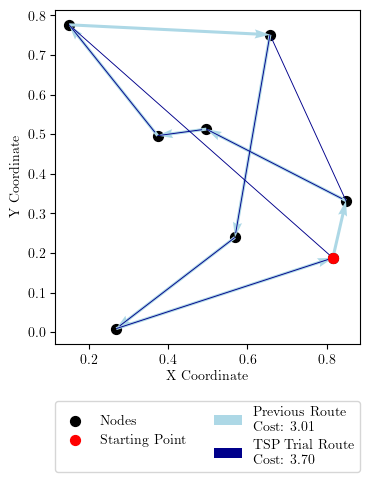

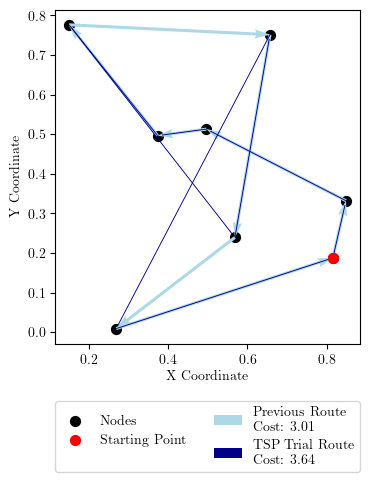

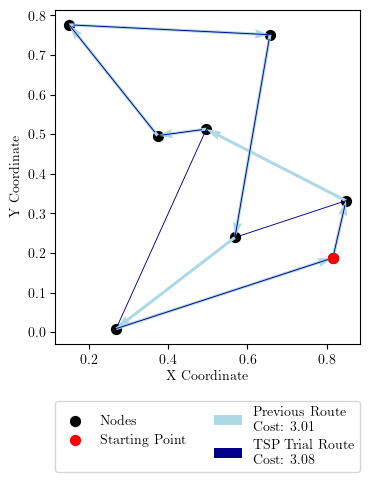

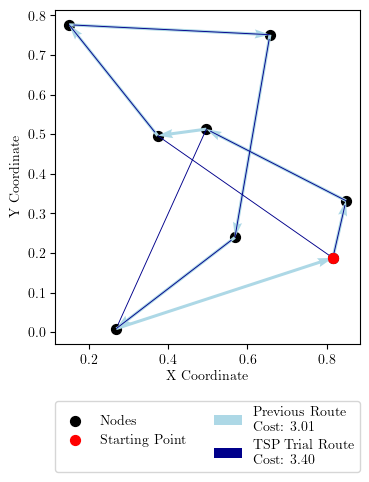

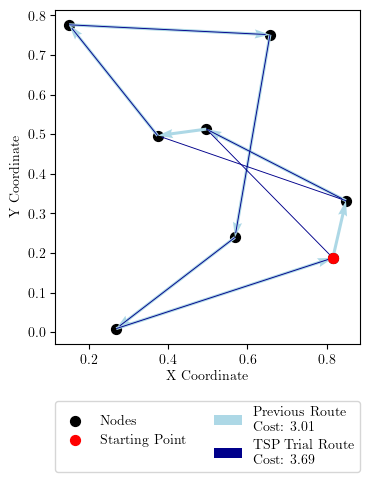

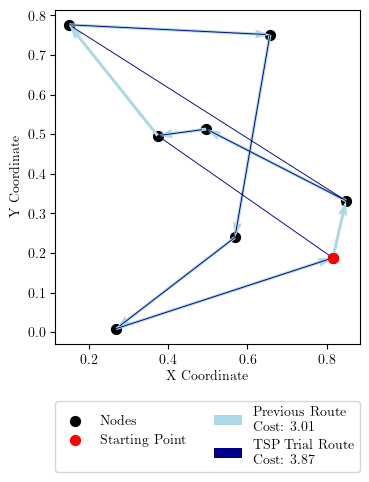

Reached maximum number of iterations for temperature 0.1. :(


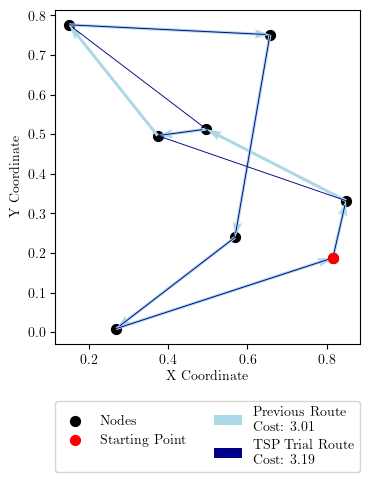

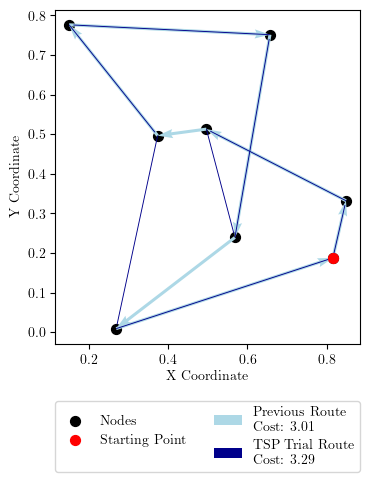

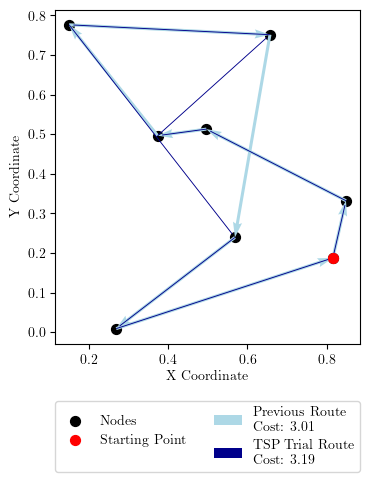

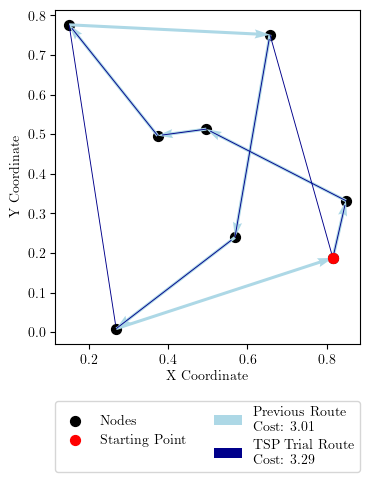

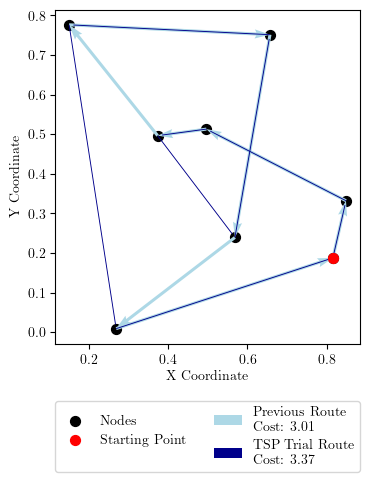

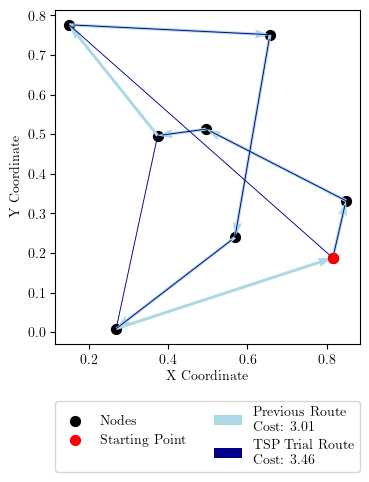

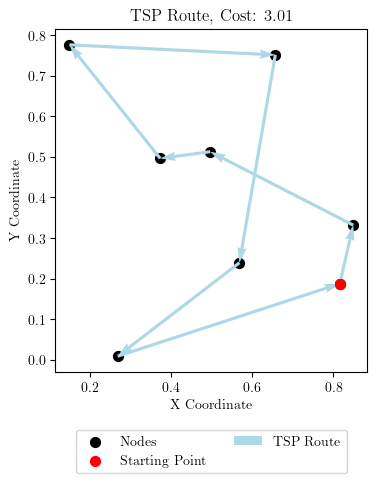

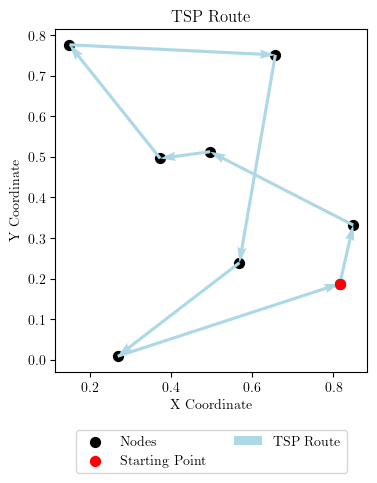

In [7]:
route_sim_annealing_rnd_N_10, cost_sim_annealing_rnd_N_10 = simmulated_annealing_tsp(rand_nodes_N_10, start_point_index=0, traffic_factor=traffic_factor_no_traffic)
plot_tsp_route(rand_nodes_N_10, 
               route_sim_annealing_rnd_N_10,
               figsize=(5, 5),
               arrow_width=0.01,
               output_path="presentation_figures/simulated_annealing_route_rnd_N_10.pdf")

## Traffic Factor Explanation

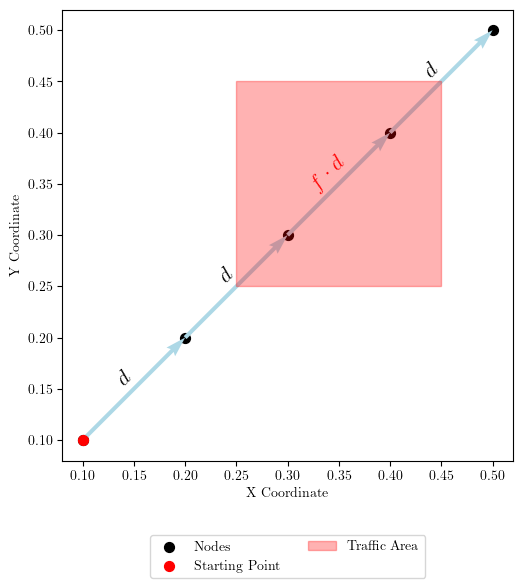

In [25]:
nodes = np.array([[0.1, 0.1],
         [0.2, 0.2],
         [0.3, 0.3],
         [0.4, 0.4],
         [0.5, 0.5]])

route = np.arange(len(nodes))

traffic_polygon = np.array([[0.25, 0.25],
                   [0.45, 0.25],
                   [0.45, 0.45],
                   [0.25, 0.45]])

cost = None

output_path = 'presentation_figures/traffic_factor_visualization.pdf'

figsize=(6, 6)

arrow_width = 0.009
arrow_color = 'lightblue'
node_dot_size = 50
node_color='black'
want_axis=True

coords = nodes[route]

coords_in_traffic_polygon = np.array([coord for coord in coords if check_if_in_polygon(coord, traffic_polygon)])


plt.figure(figsize=figsize)

# scatter nodes
plt.scatter(nodes[:, 0], nodes[:, 1], color=node_color, label='Nodes',zorder = 1, s=node_dot_size)

# starting point
plt.scatter(coords[0, 0], coords[0, 1], color='red', label='Starting Point', zorder = 2, s=node_dot_size)

if not route is None:
    # direction vectors
    dx = coords[1:, 0] - coords[:-1, 0]
    dy = coords[1:, 1] - coords[:-1, 1]

    plt.quiver(
        coords[:-1, 0],   # arrow start x
        coords[:-1, 1],   # arrow start y
        dx,               # x direction
        dy,               # y direction
        angles='xy',
        scale_units='xy',
        scale=1,
        width=arrow_width,
        color=arrow_color
    )

if traffic_polygon is not None:
    traffic_patch = plt.Polygon(traffic_polygon, color='red', alpha=0.3, label='Traffic Area')
    plt.gca().add_patch(traffic_patch)

plt.gca().set_aspect('equal')

# plt.title('TSP Route')
if not cost is None:
    plt.title(f"TSP Route, Cost: {cost:.2f}")

if want_axis:
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
else:
    plt.axis(False)

for (coord_1, coord_2) in zip(coords[:-1], coords[1:]):
    x = (coord_2[0] + coord_1[0]) / 2 - 0.01
    y = (coord_2[1] + coord_1[1]) / 2 + 0.01

    if coord_1 in coords_in_traffic_polygon and coord_2 in coords_in_traffic_polygon:
        plt.text(x, y, r'$f \cdot d$', fontsize=16, color='red', ha='center', va='center', rotation=45)
    else:
        plt.text(x, y, r'$d$', fontsize=16, color='black', ha='center', va='center', rotation=45)
    

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.tight_layout()

if output_path is not None:
    plt.savefig(output_path, bbox_inches='tight')

plt.show()
